# Making Optimizers

In this section we review some famous optimizers (and their update rules). Note that although in this workshop we implemented these manually, all of these optimizers are already pre-defined in `torch.optim`.

In [3]:
import torch

<img src="https://images.prismic.io/encord/6ab35a72-2af7-4ebd-8e80-9d9b3ace3197_image4.gif" alt="drawing" width="1000"/>
<img src="https://i.sstatic.net/EgSCN.png" alt="drawing" width="1000"/>

### SGD with momentum

SGD with Momentum improves upon standard Stochastic Gradient Descent by adding a velocity term that helps the optimizer build speed in the direction of the gradient, allowing it to move faster through flat regions and converge more efficiently. This technique also helps in reducing the oscillations along the gradient path, especially in areas where the landscape is steep, thus stabilizing the update process.

Momentum achieves this by maintaining an exponential moving average of past gradients, allowing the optimizer to "remember" previous gradients and accelerate in their direction. This approach can lead to faster convergence and a smoother path to the minimum of the loss function.

#### Update Rule
For each parameter $\theta$, the SGD with Momentum update rule is:
$$v = \beta \cdot v + (1 - \beta) \cdot \nabla_{\theta} J(\theta)$$
$$\theta = \theta - \eta \cdot v$$
where:
- $\eta$ (learning rate) determines the step size.
- $v$ is the "velocity," an accumulation of past gradients.
- $\beta$ is the momentum coefficient, typically set between 0.9 and 0.99, controlling the influence of past gradients on the current update.
- $\nabla_{\theta} J(\theta)$ is the gradient of the loss function with respect to the parameter.

In [1]:
class SGD_Momentum:
    def __init__(self, params, lr=0.01, momentum=0.9):
        self.params = list(params)
        self.lr = lr
        self.momentum = momentum
        self.velocities = [torch.zeros_like(p.data) for p in self.params]

    def step(self):
        for i, p in enumerate(self.params):
            if p.grad is None:
                continue
            self.velocities[i] = self.momentum * self.velocities[i] + (1 - self.momentum) * p.grad
            self.params[i].data -= self.lr * self.velocities[i]

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()


**Reminder**: When training a model with pytorch, we always had these three lines of code in this order: `optimizer.zero_grad()`, then `loss.backward()`, and finally `optimizer.step()`. Thus our optimizer must have `zero_grad()` and `step()` functions. `zero_grad()` resets the gradient calculations for each parameter, and `step()` updates the parameters based on the update rule.

In [69]:
# Example usage
from torch.autograd.functional import jacobian
import numpy as np
def power(x):
    return torch.log(x**2)
x = torch.tensor([1.0, 2.0, 3.0, 4.0], requires_grad=True)
print(jacobian(power, x).sum())
for i in range(100):
	op = SGD_Momentum([x], 1000)
	op.zero_grad()
	y = jacobian(power, x, create_graph=True).sum()
	y.backward()
	op.step()
x, y, print(jacobian(power, x).sum())

tensor(4.1667)
tensor(0.1413)


(tensor([201.4888,  58.4880,  42.3131,  40.0898], requires_grad=True),
 tensor(0.1416, grad_fn=<SumBackward0>),
 None)

### Adagrad

Adagrad (Adaptive Gradient) is an optimization algorithm that adjusts the learning rate based on the frequency of updates for each parameter. This approach is beneficial for problems with sparse data or for models with parameters that require different step sizes for effective learning. In Adagrad, parameters that receive frequent updates get a smaller learning rate, while those with infrequent updates get a larger one. This adaptive adjustment can improve convergence, particularly for models with large numbers of features.

#### Update Rule
For each parameter $\theta$, Adagrad maintains a running sum of squared gradients and uses it to scale the learning rate:
1. **Accumulation of Squared Gradients**:
   $$G = G + \nabla_{\theta} J(\theta)^2$$
2. **Parameter Update**:
   $$\theta = \theta - \frac{\eta}{\sqrt{G + \epsilon}} \cdot \nabla_{\theta} J(\theta)$$
   
   where:
   - $G$ is the sum of the squares of past gradients (initialized as zero).
   - $\eta$ is the initial learning rate.
   - $\epsilon$ is a small constant (e.g., $1 \times 10^{-8}$) to prevent division by zero.

In [4]:
class Adagrad:
    def __init__(self, params, lr=0.01, eps=1e-8):
        self.params = list(params)
        self.lr = lr
        self.eps = eps
        self.G = [torch.zeros_like(p) for p in self.params]

    def step(self):
        for i, p in enumerate(self.params):
            if p.grad is None:
                continue
            grad = p.grad
            self.G[i] += grad ** 2
            adjusted_lr = self.lr / (self.G[i] + self.eps).sqrt()
            p.data -= adjusted_lr * grad

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()


### RMSprop

RMSprop (Root Mean Square Propagation) is an optimization algorithm that builds upon Adagrad by modifying how accumulated gradients are computed. While Adagrad’s accumulation of squared gradients can lead to overly small learning rates over time, RMSprop introduces a moving average of squared gradients, allowing it to better handle non-stationary objectives and preventing the learning rate from decaying too quickly. This modification makes RMSprop effective for optimizing deep neural networks.

#### Update Rule
For each parameter $\theta$, RMSprop maintains a moving average of the squared gradients, calculated as follows:
1. **Moving Average of Squared Gradients**:
   $$E[g^2] = \beta \cdot E[g^2] + (1 - \beta) \cdot \nabla_{\theta} J(\theta)^2$$
2. **Parameter Update**:
   $$\theta = \theta - \frac{\eta}{\sqrt{E[g^2] + \epsilon}} \cdot \nabla_{\theta} J(\theta)$$

   where:
   - $E[g^2]$ is the moving average of squared gradients (initialized to zero).
   - $\eta$ is the learning rate.
   - $\beta$ is the decay rate for the moving average, typically set to around 0.9.
   - $\epsilon$ is a small constant (e.g., $1 \times 10^{-8}$) to prevent division by zero.

In [20]:
from torch.optim import Optimizer

class RMSprop(Optimizer):
    def __init__(self, params, lr=0.01, beta=0.9, eps=1e-8):
        defaults = dict(lr=lr, beta=0.9, eps=1e-8)
        super().__init__(params, defaults)
        self.params = list(params)
        self.lr = lr
        self.beta = beta
        self.eps = eps
        self.sq_avg = [torch.zeros_like(p) for p in self.params]

    def step(self):
        for i, p in enumerate(self.params):
            if p.grad is None:
                continue
            self.sq_avg[i] = self.beta * self.sq_avg[i] + (1 - self.beta) * p.grad ** 2
            p.data -= self.lr * p.grad / (self.sq_avg[i].sqrt() + self.eps)

    def zero_grad(self):
        for p in self.params:
            p.grad = None


### Adam (Adaptive Moment Estimation)

Adam is an optimization algorithm that integrates the concepts of **momentum** and **adaptive learning rates**. It uses both a moving average of the gradients (like momentum) and a moving average of squared gradients (like RMSprop). Adam has become a preferred optimizer in many deep learning tasks because of its robust convergence properties and ability to handle noisy gradients and sparse data.

Adam maintains two moving averages for each parameter:
1. **The first moment** ($m$) — a running average of the gradients.
2. **The second moment** ($v$) — a running average of the squared gradients.

To prevent bias at the beginning of training (when both $m$ and $v$ are near zero), Adam includes bias correction terms.

#### Update Rule
For each parameter $\theta$:
1. **Update biased first moment estimate**:
   $$m = \beta_1 \cdot m + (1 - \beta_1) \cdot \nabla_{\theta} J(\theta)$$
2. **Update biased second moment estimate**:
   $$v = \beta_2 \cdot v + (1 - \beta_2) \cdot (\nabla_{\theta} J(\theta))^2$$
3. **Compute bias-corrected estimates**:
   $$\hat{m} = \frac{m}{1 - \beta_1^t}$$
   $$\hat{v} = \frac{v}{1 - \beta_2^t}$$
4. **Parameter update**:
   $$\theta = \theta - \frac{\eta}{\sqrt{\hat{v}} + \epsilon} \cdot \hat{m}$$

Where:
- $\eta$ is the learning rate.
- $\beta_1$ (e.g., 0.9) is the decay rate for the first moment (momentum).
- $\beta_2$ (e.g., 0.999) is the decay rate for the second moment (adaptive learning rate).
- $\epsilon$ is a small constant to prevent division by zero.
- $t$ is the time step or iteration count, starting at 1.


In [9]:
class Adam:
    def __init__(self, params, lr=0.001, betas=(0.9, 0.999), eps=1e-8):
        self.params = list(params)
        self.lr = lr
        self.beta1, self.beta2 = betas
        self.eps = eps
        self.m = [torch.zeros_like(p.data) for p in self.params]
        self.v = [torch.zeros_like(p.data) for p in self.params]
        self.t = 0

    def step(self):
        self.t += 1
        for i, p in enumerate(self.params):
            if p.grad is None:
                continue
            g = p.grad
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * g * g

            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)

            p.data -= self.lr * m_hat / (v_hat.sqrt() + self.eps)

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()


# Schedulers

There is a fine balance between a high and low learning rate we need to maintain. A large lerning rate might cause the model to overshoot optimal weights and never converge. A small learning rate might lead to painfully slow convergence or getting stuck in a local minimum.

How do we get the benifits of both large and small learning rate? We first have a large learning rate to get close to the minimum quickly, then we make the learning rate smaller to have a smooth convergence. This is basically what schedulers do.

In pytorch, schedulers work alongside optimizers. In other words, we first need to define the optimizer, then wrap it around a scheduler. Also we need to call `scheduler.step()` in each epoch, so the learning rate updates.

### Step Decay

This reduces the learning rate by multiplying it with `gamma` every `step_size` epochs.

For example in the code below we have:
- Epochs 0–4: LR = 0.1
- Epochs 5–9: LR = 0.01
- Epochs 10–14: LR = 0.001

In [21]:
from torch.optim.lr_scheduler import StepLR

optimizer = RMSprop([x])
scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

### Exponential Decay

This reduces the learning rate exponentially each epoch:
$$\text{lr}_t = \text{lr}_0 \cdot \gamma^t$$

In [ ]:
from torch.optim.lr_scheduler import ExponentialLR

scheduler = ExponentialLR(optimizer, gamma=0.95)

### ReduceLROnPlateau

This is an adaptive scheduler — it reduces LR only when the validation loss stops improving.

for example in the code below we have:
- `factor=0.1`: reduce LR by 10×
- `patience=2`: wait 2 epochs with no improvement before reducing


In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

Note: In each epoch, we should call `scheduler.step(val_loss)` if we want to use this scheduler

# Comparison

We plan on using the dataset and model from the previous workshop and compare how each optimizer/scheduler compare.

First we load the dataset and define the model (just like the previous workshop).

In [22]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [23]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=1000)

In [24]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.w1 = nn.Parameter(torch.randn(784, 128) * 0.01)
        self.b1 = nn.Parameter(torch.zeros(128))
        self.w2 = nn.Parameter(torch.randn(128, 10) * 0.01)
        self.b2 = nn.Parameter(torch.zeros(10))

    def forward(self, x):
        x = x.view(-1, 784)
        z1 = x @ self.w1 + self.b1
        a1 = F.relu(z1)
        z2 = a1 @ self.w2 + self.b2
        return z2

We also define a function used for training (and another function for testing) to compare the optimizers more easily.

In [41]:
def train_model(model, optimizer, scheduler=None, epochs=10, model_name='best_model.pt'):
    train_losses = []
    best_accuracy = 0

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images)
            loss = F.cross_entropy(preds, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()

        if scheduler:
            scheduler.step()

        model.eval()

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        current_accuracy = test_model(model)
        if current_accuracy > best_accuracy:
            torch.save(model, model_name)
            best_accuracy = current_accuracy

        print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {current_accuracy:.4f}")
    
    return train_losses

def test_model(model, print_info=False):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            pred = outputs.argmax(dim=1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
    accuracy = correct / total
    if print_info:
        print(f"Test Accuracy: {accuracy:.4f}")
    return accuracy


## Experiments

### Experiment 1: SGD with Momentum

In [ ]:
model = MLP().to(device)
optimizer = SGD_Momentum(model.parameters(), lr=0.1, momentum=0.9)

losses_sgd = train_model(model, optimizer, epochs=10, model_name='best_sgd_mode.pt')
test_model(model, print_info=True)

Epoch 1: Loss = 0.5924, Accuracy = 0.9234
Epoch 2: Loss = 0.2516, Accuracy = 0.9387
Epoch 3: Loss = 0.1919, Accuracy = 0.9509
Epoch 4: Loss = 0.1547, Accuracy = 0.9588
Epoch 5: Loss = 0.1293, Accuracy = 0.9645
Epoch 6: Loss = 0.1101, Accuracy = 0.9669
Epoch 7: Loss = 0.0964, Accuracy = 0.9696
Epoch 8: Loss = 0.0851, Accuracy = 0.9727
Epoch 9: Loss = 0.0760, Accuracy = 0.9726
Epoch 10: Loss = 0.0688, Accuracy = 0.9747


0.9747

In [31]:
loaded_model = torch.load('best_model.pt').to('cpu')

C:\Users\arefz\AppData\Local\Temp\ipykernel_31072\358602248.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model = torch.load('best_model.pt').to('cpu')


In [32]:
image, label = test_dataset[0]
pred = loaded_model(image)
print(pred)

tensor([[  0.3567,  -5.4553,   3.5399,   5.7832,  -7.3092,  -0.6940, -13.1886,
          13.9473,   0.9004,   1.9074]], grad_fn=<AddBackward0>)


### Experiment 2: Adam

In [ ]:
model = MLP().to(device)
optimizer = Adam(model.parameters(), lr=0.001)

losses_adam = train_model(model, optimizer, epochs=10, model_name='best_model_adam.pt')
test_model(model, print_info=True)

Epoch 1: Loss = 0.3867, Accuracy = 0.9388
Epoch 2: Loss = 0.1790, Accuracy = 0.9578
Epoch 3: Loss = 0.1246, Accuracy = 0.9676
Epoch 4: Loss = 0.0936, Accuracy = 0.9695
Epoch 5: Loss = 0.0734, Accuracy = 0.9711
Epoch 6: Loss = 0.0590, Accuracy = 0.9768
Epoch 7: Loss = 0.0485, Accuracy = 0.9773
Epoch 8: Loss = 0.0396, Accuracy = 0.9783
Epoch 9: Loss = 0.0326, Accuracy = 0.9785
Epoch 10: Loss = 0.0270, Accuracy = 0.9781


0.9781

### Experiment 3: SGD with scheduler

In [ ]:
model = MLP().to(device)
optimizer_step = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
scheduler_step = torch.optim.lr_scheduler.StepLR(optimizer_step, step_size=5, gamma=0.1)

losses_scheduler = train_model(model, optimizer_step, scheduler_step, epochs=10, model_name='best_scheduler_model.pt')
test_model(model, print_info=True)

Epoch 1: Loss = 0.2730, Accuracy = 0.9612
Epoch 2: Loss = 0.1100, Accuracy = 0.9709
Epoch 3: Loss = 0.0812, Accuracy = 0.9638
Epoch 4: Loss = 0.0660, Accuracy = 0.9737
Epoch 5: Loss = 0.0507, Accuracy = 0.9746
Epoch 6: Loss = 0.0214, Accuracy = 0.9812
Epoch 7: Loss = 0.0154, Accuracy = 0.9812
Epoch 8: Loss = 0.0134, Accuracy = 0.9817
Epoch 9: Loss = 0.0119, Accuracy = 0.9820
Epoch 10: Loss = 0.0109, Accuracy = 0.9817


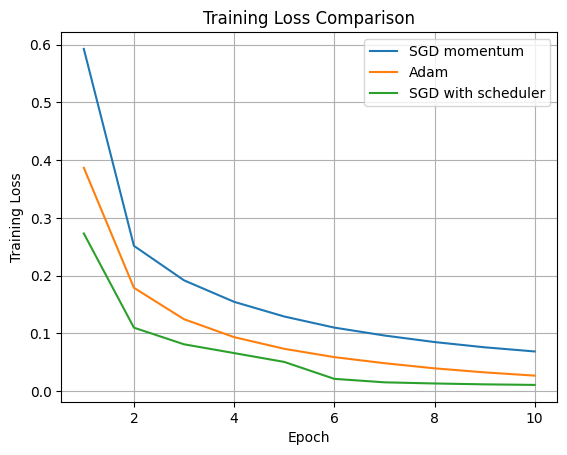

In [40]:
epochs = range(1, 11)
plt.plot(epochs, losses_sgd, label='SGD momentum')
plt.plot(epochs, losses_adam, label='Adam')
plt.plot(epochs, losses_scheduler, label='SGD with scheduler')

plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True)
plt.show()